# TCGA & Compass NMD Dataset

We need to cut the annotated region from the whole prediction and reshape it to the correct size.

In [19]:
import os
from PIL import Image
import pandas as pd
from PIL import Image
import numpy as np
from histokit.savers import HDF5Saver
import pandas as pd
import os
import shutil
from tqdm import tqdm
from histokit.file_utils.file_check import check_gt_pred_folders
import os
Image.MAX_IMAGE_PIXELS = None

classes = {
    "Tissue": [128, 128, 128],
    "Background": [0, 0, 0],
    "Fold": [255, 99, 71],
    "Dark.Spot": [0, 255, 0],
    "Pen": [255, 0, 0],
    "Edge": [255, 0, 255],
    "Out.Of.Focus": [75, 0, 130],
}


pred_dir = "/mnt/warehouse/Projects/HE/Data/Artifacts Segmentation/TCGA_CompassNMD/Results/GrandQC_converted_tissue/mask_qc/"
svs_dir = "/mnt/warehouse/Projects/HE/Data/Artifacts Segmentation/TCGA_CompassNMD/svs/"
gt_dir = "/mnt/warehouse/Projects/HE/Data/Artifacts Segmentation/TCGA_CompassNMD/10x/gt_mask/"
df_coords = pd.read_csv("/mnt/warehouse/Projects/HE/Data/Artifacts Segmentation/TCGA_CompassNMD/10x/annotated_coords.csv")


In [20]:
df = pd.read_csv('/mnt/warehouse/Projects/HE/Data/Artifacts Segmentation/TCGA_CompassNMD/10x/annotated_coords.csv')
df.head()
svs_path = df["svs_path"].values
svs_path = [os.path.basename(s).split(".svs")[0] for s in svs_path]

df["svs_name"] = svs_path
df.head()

,svs_path,patch_path,matched_path,target_mag,objective_mag,target_downsample,matched_level,level_downsample,matched_level_mag,resize_scale,...,y_10x,patch_width_10x,patch_height_10x,x0,y0,width0,height0,x0_end,y0_end,svs_name
0,/mnt/warehouse/Projects/HE/Data/Artifacts Segm...,/mnt/warehouse/Projects/HE/Data/Artifacts Segm...,/mnt/warehouse/Projects/HE/Data/Artifacts Segm...,10,20.0,2.0,0,1.0,20.0,0.5,...,0,8963,5954,0,0,17926,11908,17926,11908,TCGA-CV-7099-01A-02-BS2.1e152adb-e0cb-4962-800...
1,/mnt/warehouse/Projects/HE/Data/Artifacts Segm...,/mnt/warehouse/Projects/HE/Data/Artifacts Segm...,/mnt/warehouse/Projects/HE/Data/Artifacts Segm...,10,50.0,5.0,1,4.0,12.5,0.8,...,5601,3712,2768,33605,28005,18560,13840,52165,41845,2-12_he_1
2,/mnt/warehouse/Projects/HE/Data/Artifacts Segm...,/mnt/warehouse/Projects/HE/Data/Artifacts Segm...,/mnt/warehouse/Projects/HE/Data/Artifacts Segm...,10,50.0,5.0,1,4.0,12.5,0.8,...,592,6416,11392,24085,2960,32080,56960,56165,59920,33-00_he
3,/mnt/warehouse/Projects/HE/Data/Artifacts Segm...,/mnt/warehouse/Projects/HE/Data/Artifacts Segm...,/mnt/warehouse/Projects/HE/Data/Artifacts Segm...,10,20.0,2.0,0,1.0,20.0,0.5,...,4546,6482,6619,10872,9092,12964,13238,23836,22330,TCGA-08-0520-01Z-00-DX1.2d50b1bc-c1d8-41a4-b42...
4,/mnt/warehouse/Projects/HE/Data/Artifacts Segm...,/mnt/warehouse/Projects/HE/Data/Artifacts Segm...,/mnt/warehouse/Projects/HE/Data/Artifacts Segm...,10,50.0,5.0,1,4.0,12.5,0.8,...,0,5249,6181,25150,0,26245,30905,51395,30905,11-22_he


In [3]:
df.columns

Index(['svs_path', 'patch_path', 'matched_path', 'target_mag', 'objective_mag',
       'target_downsample', 'matched_level', 'level_downsample',
       'matched_level_mag', 'resize_scale', 'coarse_scale', 'coarse_score',
       'match_score', 'x_10x', 'y_10x', 'patch_width_10x', 'patch_height_10x',
       'x0', 'y0', 'width0', 'height0', 'x0_end', 'y0_end', 'svs_name'],
      dtype='str')

In [23]:
from histokit.slide.slide import Slide

folders_processed = ["/mnt/warehouse/Projects/HE/Data/Artifacts Segmentation/TCGA_CompassNMD/Results/GrandQC_converted_tissue/"]
svs_dir = "/mnt/warehouse/Projects/HE/Data/Artifacts Segmentation/TCGA_CompassNMD/svs/"

target_mag = 10

for folder in tqdm(folders_processed, desc="Processing folders"):
    print(f"Processing folder: {folder}")
    mask_dir = os.path.join(folder, "mask_qc")
    parsed_dir = os.path.join(folder, "masks_cropped_numeric")

    parsed_color_dir = os.path.join(folder,"masks_cropped_color")
    print("Parsed numeric masks will be saved to:", parsed_dir)
    print("Parsed color masks will be saved to:", parsed_color_dir)

    os.makedirs(parsed_color_dir, exist_ok=True)

    os.makedirs(parsed_dir, exist_ok=True)

    #print("Processing folder:", folder)
    print(os.listdir(mask_dir))

    for m in os.listdir(mask_dir):
            print(os.path.join(svs_dir, m.replace(".png", ".svs")))
            #wsi = Slide(os.path.join(svs_dir, m.replace(".png", "")))
            #size = wsi.get_full_slide_size(mag = 10)
            name = m.split(".png")[0]
            rows = df[df["svs_name"] == name]

            for row in rows.itertuples(index=False):
                try:
                    save_name = row.patch_path.split("/")[-1].replace(".tiff", ".png")
                    out_path = os.path.join( parsed_color_dir, f"{save_name}")

                    if os.path.exists(out_path):
                        try:
                            with Image.open(out_path) as img:
                                img.verify()

                            with Image.open(out_path) as img:
                                img.load()

                            print(f"Skipping existing valid file: {save_name}.png")
                            continue

                        except Exception as e:
                            print(f"Existing file is corrupted, regenerating: {out_path}")
                            print(e)

                    print(f"Processing {folder} file: {save_name}.png")
                    img = Image.open(os.path.join(mask_dir, m))
                    #img = img.resize((size[0], size[1]), Image.NEAREST)
                    slide = np.array(img)[row.y_10x:row.y_10x + row.patch_height_10x, row.x_10x:row.x_10x + row.patch_width_10x]
                    print(f"Slide shape: {slide.shape}, Row coordinates: y={row.y_10x}, x={row.x_10x}, height={row.patch_height_10x}, width={row.patch_width_10x}")

                    slide_color = np.zeros((slide.shape[0], slide.shape[1], 3), dtype=np.uint8)
                    slide_color[slide == 0] = [0, 0, 0]
                    slide_color[slide == 1] = [128, 128, 128]
                    slide_color[slide == 2] = [255, 99, 71]
                    slide_color[slide == 3] = [0, 255, 0]
                    slide_color[slide == 4] = [255, 0, 0]
                    slide_color[slide == 5] = [255, 0, 255]
                    slide_color[slide == 6] = [75, 0, 130]

                    Image.fromarray(slide_color).save(os.path.join(parsed_color_dir, f"{save_name}"))
                    print(f"Saved color mask to: {os.path.join(parsed_color_dir, f'{save_name}.png')}")
                except Exception as e:
                    print(f"Error processing {m}")
                    print(e)

Processing folders:   0%|          | 0/1 [00:00<?, ?it/s]

Processing folder: /mnt/warehouse/Projects/HE/Data/Artifacts Segmentation/TCGA_CompassNMD/Results/GrandQC_converted_tissue/
Parsed numeric masks will be saved to: /mnt/warehouse/Projects/HE/Data/Artifacts Segmentation/TCGA_CompassNMD/Results/GrandQC_converted_tissue/masks_cropped_numeric
Parsed color masks will be saved to: /mnt/warehouse/Projects/HE/Data/Artifacts Segmentation/TCGA_CompassNMD/Results/GrandQC_converted_tissue/masks_cropped_color
['TCGA-EC-A1QX-01Z-00-DX1.D94B9C3B-F06F-4300-B492-E2534AF4D703.png', '10-99_he.tiff_mask.png', '390-02_he_2.tiff_mask.png', 'TCGA-KM-8441-01Z-00-DX1.D2CA0ADE-7EDF-49A6-989C-2761F1CFE340.tiff_mask.png', '33-12_he_2.tiff_mask.png', 'TCGA-CJ-5683-01Z-00-DX1.4758DFEF-5B66-43AC-B88B-FFF4079DB129.png', 'TCGA-KM-8441-01Z-00-DX1.D2CA0ADE-7EDF-49A6-989C-2761F1CFE340.png', 'TCGA-AX-A1CF-01Z-00-DX2.97DE8134-0D44-4FCE-BA8A-46AD7D215133.tiff_mask.png', '47-07b_he_2.tiff_mask.png', 'TCGA-2Y-A9GY-01Z-00-DX1.9AF8DAB8-B99C-4484-A065-20E7345E1FF4.tiff_mask.png',

Processing folders: 100%|██████████| 1/1 [00:09<00:00,  9.32s/it]

Skipping existing valid file: TCGA-08-0520-01Z-00-DX1.2d50b1bc-c1d8-41a4-b42f-19d9916a5ef6_R1.png.png
/mnt/warehouse/Projects/HE/Data/Artifacts Segmentation/TCGA_CompassNMD/svs/47-07b_he_2.svs
Skipping existing valid file: 47-07b_he_2_R1.png.png


Processing folders: 100%|██████████| 1/1 [00:09<00:00,  9.32s/it]


In [24]:
folders_processed = ["/mnt/warehouse/Projects/HE/Data/Artifacts Segmentation/TCGA_CompassNMD/Results/GrandQC_converted_tissue/"]
masks_dir = "/mnt/warehouse/Projects/HE/Data/Artifacts Segmentation/TCGA_CompassNMD/10x/annotated_masked_overlap/"
masks_names = os.listdir(masks_dir)

for folder in tqdm(folders_processed, desc="Processing folders"):
    parsed_color_dir = os.path.join(folder, "masks_cropped_color")

    for m_n in tqdm(masks_names, desc="Processing masks", leave=False):
        try:
            mask_path = os.path.join(masks_dir, m_n)
            pred_path = os.path.join(parsed_color_dir, m_n)

            mask = np.array(Image.open(mask_path).convert("L"))
            pred_mask = np.array(Image.open(pred_path).convert("RGB"))

            if mask.shape != pred_mask.shape[:2]:
                print(f"Shape mismatch for {m_n} in {folder}: mask {mask.shape}, pred {pred_mask.shape}")
                continue

            pred_mask[mask == 255] = [0, 0, 0]

            Image.fromarray(pred_mask).save(pred_path)

        except Exception as e:
            print(f"Error processing {m_n} in folder {folder}: {e}")

Processing folders: 100%|██████████| 1/1 [00:06<00:00,  6.54s/it]A


In [25]:
from histokit.segmentation.evaluate.eval import evaluate_rgb_mask


gt_dir = "/mnt/warehouse/Projects/HE/Data/Artifacts Segmentation/TCGA_CompassNMD/10x/gt_mask/"
pred_dir = "/mnt/warehouse/Projects/HE/Data/Artifacts Segmentation/TCGA_CompassNMD/Results/GrandQC_converted_tissue/masks_cropped_color/"
vis_dir = "/mnt/warehouse/Projects/HE/Data/Artifacts Segmentation/TCGA_CompassNMD/Results/GrandQC_converted_tissue/masks_cropped_color_vis/"

os.makedirs(vis_dir, exist_ok=True)

res_binary_list = []
res_multiclass_list = []


for gt_path in tqdm(os.listdir(gt_dir), desc="Evaluating masks"):
    gt_name = os.path.basename(gt_path)

    gt = Image.open(os.path.join(gt_dir, gt_path))
    pred = Image.open(os.path.join(pred_dir, f"{gt_name}"))

    if gt.size != pred.size:
        pred = pred.resize(gt.size, Image.NEAREST)

    mask_gt = np.array(gt)
    mask_pred = np.array(pred)


    res_binary, res_multiclass = evaluate_rgb_mask(
            mask_gt=mask_gt,
            mask_pred=mask_pred,
            mask_basename=gt_name,
            vis_dir=vis_dir,
            method="GrandQC Original",
            tissue_class=[128, 128, 128],
            bg_class=[0, 0, 0],
            multiclass=True,
            class_dict=classes,
        )

    res_binary["Mode"] = "Original GrandQC"
    res_binary["Overlap"] = 0
    res_binary["Sigma"] = None
    res_multiclass["Mode"] = "Original GrandQC"
    res_multiclass["Overlap"] = 0
    res_multiclass["Sigma"] = None

    res_binary_list.append(res_binary)
    res_multiclass_list.append(res_multiclass)


df_binary = pd.DataFrame(res_binary_list)
df_multiclass = pd.DataFrame(res_multiclass_list)

df_binary.to_csv("/mnt/warehouse/Projects/HE/Data/Artifacts Segmentation/TCGA_CompassNMD/Results/GrandQC_converted_tissue/grandQC_binary.csv", index=False)
df_multiclass.to_csv("/mnt/warehouse/Projects/HE/Data/Artifacts Segmentation/TCGA_CompassNMD/Results/GrandQC_converted_tissue/grandQC_multiclass.csv", index=False)


Evaluating masks: 100%|██████████| 25/25 [10:07<00:00, 24.28s/it]


In [26]:
print(df_binary.head())
print(df_binary.RECALL.dropna().mean())
print(df_binary.RECALL.dropna().median())

print(df_binary.DICE.dropna().mean())
print(df_binary.DICE.dropna().median())

print(df_binary.FDR.dropna().mean())
print(df_binary.FDR.dropna().median())

             Method              Mode  \
0  GrandQC Original  Original GrandQC   
1  GrandQC Original  Original GrandQC   
2  GrandQC Original  Original GrandQC   
3  GrandQC Original  Original GrandQC   
4  GrandQC Original  Original GrandQC   

                                               Image        TP        TN  \
0                                 390-02_he_2_R1.png   2423310  27415032   
1                                   2-12_he_1_R4.png   5089661   4824801   
2                                     1083_he_R1.png         0  19490861   
3                                 47-07b_he_2_R1.png  10221367  37049133   
4  TCGA-KM-8441-01Z-00-DX1.D2CA0ADE-7EDF-49A6-989...   4640942   3770061   

        FP       FN      DICE   JACCARD  PRECISION    RECALL  ACCURACY  \
0   945982  3935340  0.498216  0.331750   0.719234  0.381104  0.859408   
1   280350   489604  0.929680  0.868600   0.947793  0.912246  0.927937   
2  2399155        0  0.000000  0.000000   0.000000       NaN  0.890400   


In [48]:
df = pd.read_csv("/mnt/warehouse/Projects/HE/Data/Artifacts Segmentation/TCGA_CompassNMD/Results/Histokit_30_06_2026/binary_metrics.csv")

metrics = [
    "TP", "TN", "FP", "FN",
    "DICE", "JACCARD", "PRECISION", "RECALL",
    "ACCURACY", "F1", "SPECIFICITY", "NPV", "FDR"
]

merged = df.merge(
    df_binary[["Image"] + metrics],
    on="Image",
    how="inner",
    suffixes=("_method", "_grandqc")
)

diff = merged[
    ["Method", "Mode", "Image", "Overlap", "Sigma"]
].copy()

for col in metrics:
    diff[col] = (
        merged[f"{col}_method"]
        - merged[f"{col}_grandqc"]
    )

diff.head()

diff.to_csv("/mnt/warehouse/Projects/HE/Data/Artifacts Segmentation/TCGA_CompassNMD/Results/Histokit_30_06_2026/diff_metrics.csv", index=False)

Number of parameter combinations: 20
                           Method  Overlap  Sigma
340  HistoKit (no postprocessing)     0.25   0.75
315  HistoKit (no postprocessing)     0.25   1.25
0    HistoKit (no postprocessing)     0.25   1.75
415  HistoKit (no postprocessing)     0.25   2.25
440  HistoKit (no postprocessing)     0.25    NaN
65   HistoKit (no postprocessing)     0.50   0.75
265  HistoKit (no postprocessing)     0.50   1.25
16   HistoKit (no postprocessing)     0.50   1.75
91   HistoKit (no postprocessing)     0.50   2.25
165  HistoKit (no postprocessing)     0.50    NaN
240  HistoKit (no postprocessing)     0.75   0.75
390  HistoKit (no postprocessing)     0.75   1.25
465  HistoKit (no postprocessing)     0.75   1.75
190  HistoKit (no postprocessing)     0.75   2.25
115  HistoKit (no postprocessing)     0.75    NaN
290  HistoKit (no postprocessing)     0.90   0.75
365  HistoKit (no postprocessing)     0.90   1.25
140  HistoKit (no postprocessing)     0.90   1.75
41   HistoKit

/tmp/ipykernel_2881553/790032254.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='F1', ax=ax, palette='Set2')


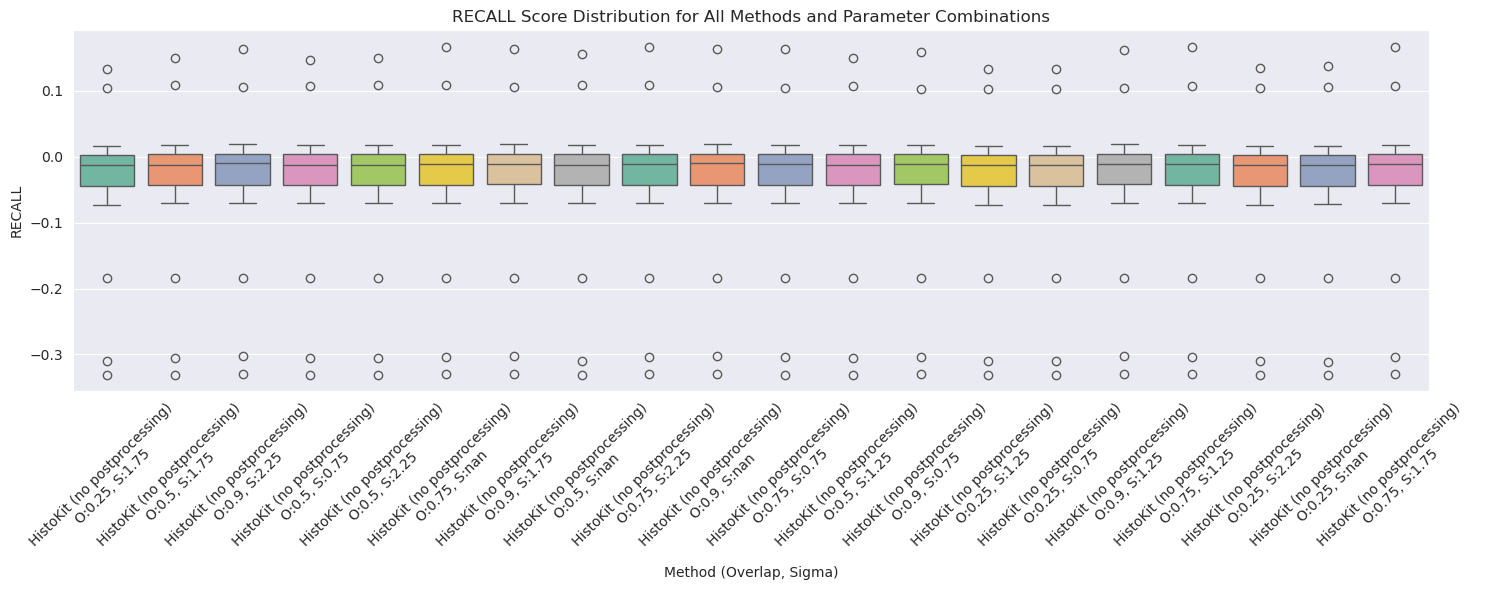

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

df = diff

# Get unique combinations of parameters
param_combinations = df[['Method', 'Overlap', 'Sigma']].drop_duplicates().sort_values(['Method', 'Overlap', 'Sigma'])
print(f"Number of parameter combinations: {len(param_combinations)}")
print(param_combinations)

# Create a label combining all parameters for x-axis
df['Label'] = df.apply(lambda row: f"{row['Method']}\nO:{row['Overlap']}, S:{row['Sigma']}", axis=1)

# Create single violinplot with all combinations
fig, ax = plt.subplots(figsize=(15, 6))

sns.boxplot(data=df, x='Label', y='F1', ax=ax, palette='Set2')
ax.set_title('RECALL Score Distribution for All Methods and Parameter Combinations')
ax.set_xlabel('Method (Overlap, Sigma)')
ax.set_ylabel('RECALL')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
import os
print("Environment Variables:")
for key, value in sorted(os.environ.items()):
    print(f"{key}={value}")

# SliDL

In [ ]:
masks_dir =

# GrandQC

In [24]:
import os
import os
from PIL import Image
import pandas as pd
from PIL import Image
import numpy as np
from histokit.savers import HDF5Saver
import pandas as pd
import os
import shutil
from tqdm import tqdm
from histokit.file_utils.file_check import check_gt_pred_folders
import os
Image.MAX_IMAGE_PIXELS = None
from histokit.segmentation.evaluate.eval import evaluate_rgb_mask

classes = {
    "Tissue": [128, 128, 128],
    "Background": [0, 0, 0],
    "Fold": [255, 99, 71],
    "Dark.Spot": [0, 255, 0],
    "Pen": [255, 0, 0],
    "Edge": [255, 0, 255],
    "Out.Of.Focus": [75, 0, 130],
}

organ = "Colon"

data_dir = f"/mnt/warehouse/Projects/HE/Data/Artifacts Segmentation/GrandQC Test Dataset/PreprocessedDataset/{organ}/10x/Results/GrandQC_05.07.2026/maps_qc"

gt_dir = f"/mnt/warehouse/Projects/HE/Data/Artifacts Segmentation/GrandQC Test Dataset/PreprocessedDataset/{organ}/10x/gt_mask"

vis_dir = f"/mnt/warehouse/Projects/HE/Data/Artifacts Segmentation/GrandQC Test Dataset/PreprocessedDataset/{organ}/10x/Results/GrandQC_05.07.2026/maps_qc_vis"

maps_qc_converted = f"/mnt/warehouse/Projects/HE/Data/Artifacts Segmentation/GrandQC Test Dataset/PreprocessedDataset/{organ}/10x/Results/GrandQC_05.07.2026/maps_qc_converted"

gt_paths = os.listdir(gt_dir)

os.makedirs(maps_qc_converted, exist_ok=True)
os.makedirs(vis_dir, exist_ok=True)

res_binary_list = []
res_multiclass_list = []

for g in tqdm(gt_paths):
    gt_name = os.path.basename(g)
    gt = Image.open(os.path.join(gt_dir, gt_name))
    pred = Image.open(os.path.join(data_dir, g+"_map_QC.png"))

    if gt.size != pred.size:
        pred = pred.resize(gt.size, Image.NEAREST)

    mask_gt = np.array(gt)
    mask_pred = np.array(pred)

    mask_pred[np.all(mask_pred == (0, 0, 0), axis=-1)] = (128, 128, 128)
    mask_pred[np.all(mask_gt == 0, axis=-1)] = 0
    mask_pred[np.all(mask_pred == 255, axis=-1)] = 128

    Image.fromarray(mask_pred).save(f"{maps_qc_converted}/{g}")



    res_binary, res_multiclass = evaluate_rgb_mask(
            mask_gt=mask_gt,
            mask_pred=mask_pred,
            mask_basename=gt_name,
            vis_dir=vis_dir,
            method="GrandQC Original",
            tissue_class=[128, 128, 128],
            bg_class=[0, 0, 0],
            multiclass=True,
            class_dict=classes,
        )

    res_binary["Mode"] = "Original GrandQC"
    res_binary["Overlap"] = 0
    res_binary["Sigma"] = None
    res_multiclass["Mode"] = "Original GrandQC"
    res_multiclass["Overlap"] = 0
    res_multiclass["Sigma"] = None

    res_binary_list.append(res_binary)
    res_multiclass_list.append(res_multiclass)


df_binary = pd.DataFrame(res_binary_list)
df_multiclass = pd.DataFrame(res_multiclass_list)

df_binary.to_csv(f"{organ}_grandQC_binary.csv", index=False)
df_multiclass.to_csv(f"{organ}_grandQC_multiclass.csv", index=False)

100%|██████████| 178/178 [14:38<00:00,  4.94s/it]


Number of parameter combinations: 20
                            Method  Overlap  Sigma
2488  HistoKit (no postprocessing)     0.25   0.75
2307  HistoKit (no postprocessing)     0.25   1.25
0     HistoKit (no postprocessing)     0.25   1.75
3021  HistoKit (no postprocessing)     0.25   2.25
3200  HistoKit (no postprocessing)     0.25    NaN
530   HistoKit (no postprocessing)     0.50   0.75
1953  HistoKit (no postprocessing)     0.50   1.25
172   HistoKit (no postprocessing)     0.50   1.75
707   HistoKit (no postprocessing)     0.50   2.25
1242  HistoKit (no postprocessing)     0.50    NaN
1774  HistoKit (no postprocessing)     0.75   0.75
2844  HistoKit (no postprocessing)     0.75   1.25
3378  HistoKit (no postprocessing)     0.75   1.75
1420  HistoKit (no postprocessing)     0.75   2.25
886   HistoKit (no postprocessing)     0.75    NaN
2132  HistoKit (no postprocessing)     0.90   0.75
2666  HistoKit (no postprocessing)     0.90   1.25
1064  HistoKit (no postprocessing)     0.90  

/tmp/ipykernel_2899481/3690960450.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='RECALL', ax=ax, palette='Set2')


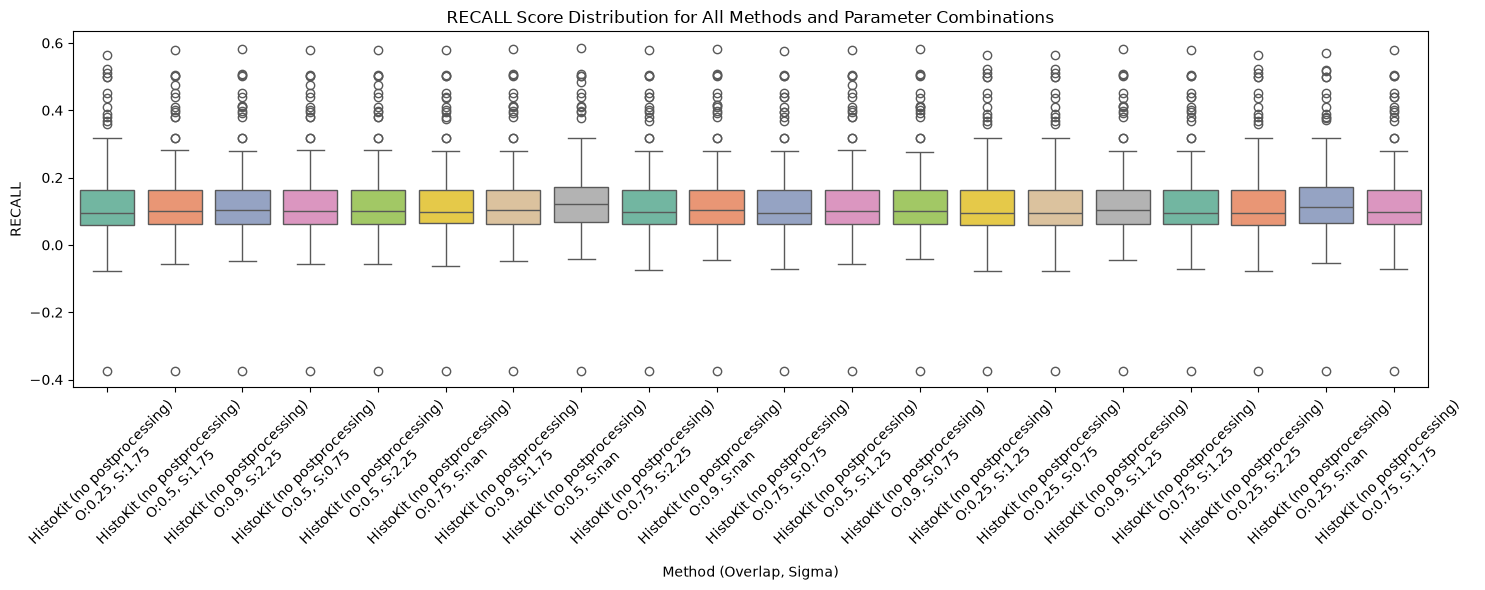

In [27]:
df_grandqc = pd.read_csv(f"Colon_grandQC_binary.csv")
df_histokit = pd.read_csv(f"/mnt/warehouse/Projects/HE/Data/Artifacts Segmentation/GrandQC Test Dataset/PreprocessedDataset/Colon/10x/Results/Histokit_30_06_2026/binary_metrics.csv")


metrics = [
    "TP", "TN", "FP", "FN",
    "DICE", "JACCARD", "PRECISION", "RECALL",
    "ACCURACY", "F1", "SPECIFICITY", "NPV", "FDR"
]

merged = df_histokit.merge(
    df_grandqc[["Image"] + metrics],
    on="Image",
    how="inner",
    suffixes=("_method", "_grandqc")
)

diff = merged[
    ["Method", "Mode", "Image", "Overlap", "Sigma"]
].copy()

for col in metrics:
    diff[col] = (
        merged[f"{col}_method"]
        - merged[f"{col}_grandqc"]
    )

diff.head()

import seaborn as sns
import matplotlib.pyplot as plt

df = diff

# Get unique combinations of parameters
param_combinations = df[['Method', 'Overlap', 'Sigma']].drop_duplicates().sort_values(['Method', 'Overlap', 'Sigma'])
print(f"Number of parameter combinations: {len(param_combinations)}")
print(param_combinations)

# Create a label combining all parameters for x-axis
df['Label'] = df.apply(lambda row: f"{row['Method']}\nO:{row['Overlap']}, S:{row['Sigma']}", axis=1)

# Create single violinplot with all combinations
fig, ax = plt.subplots(figsize=(15, 6))

sns.boxplot(data=df, x='Label', y='RECALL', ax=ax, palette='Set2')
ax.set_title('RECALL Score Distribution for All Methods and Parameter Combinations')
ax.set_xlabel('Method (Overlap, Sigma)')
ax.set_ylabel('RECALL')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#diff.to_csv("/mnt/warehouse/Projects/HE/Data/Artifacts Segmentation/TCGA_CompassNMD/Results/Histokit_30_06_2026/diff_metrics.csv", index=False)